# Advanced Object Tracking and Detection in Video Streams
## Problem Statement 3

The objective of this assignment is to build a people tracking pipeline for camera feed videos, using faster-RCNN model for detection, and SORT algorithm with a Kalman-filter-based SORT tracker.

The implementation uses the MOT17 dataset to fine-tune the faster-RCNN detection model.


**Approach:** Fine-tune a Faster R-CNN detector, then track detected objects across frames
with a Kalman-filter-based SORT tracker that includes (a) a temporal consistency check
(an identity is only confirmed after several consecutive matched frames) and (b) an
adaptive IoU gate that loosens matching tolerance for fast-moving objects.

# 1. Import Required Libraries

In [1]:
!pip install -q motmetrics torchmetrics motmetrics filterpy

import os
import glob
import time
import random
import shutil
import subprocess

import numpy as np

# motmetric specific fix
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

import pandas as pd
import cv2

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm

import motmetrics as mm
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment

import math

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [33]:
# setting device type based on available 
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif device.type == "mps":
    print("GPU: Apple Silicon (Metal Performance Shaders)")

Using device: mps
GPU: Apple Silicon (Metal Performance Shaders)


# 2. Dataset Downloading and filtering
## Dataset Configuration

For this assignment, the MOT17 dataset is used instead of SportsMOT. Both datasets are designed for multi-object tracking, with annotated video sequences and object identities across frames.

Each MOT17 sequence has the following structure:

```text
MOT17/
└── train/
    └── MOT17-04-FRCNN/
        ├── img1/          # It has video frames
        ├── gt/
        │   └── gt.txt     # Ground truth annotations
        ├── det/
        │   └── det.txt    # Detector outputs
        └── seqinfo.ini    # Sequence metadata
```
The important files used in this work are:

- **img1/** : Video frames stored as sequential images.
- **gt.txt** : Ground truth object annotations (bounding boxes and track IDs).
- **det.txt** : Pre-computed detector outputs (not used for training).
- **seqinfo.ini** : Sequence metadata such as frame size, frame rate and sequence length.


In [3]:
from google.colab import drive
drive.mount("/content/drive")

ROOT_DIR = "/content/drive/MyDrive/sem2/CV/Assignment2"
CHECKPOINT_DIR = ROOT_DIR # will be used to save training checkpoint
DATA_ROOT =  os.path.join(ROOT_DIR, "MOT17")

# order of entries in gt.txt
COLUMN_NAMES = ["frame", "id", "x", "y", "w", "h", "conf", "class", "visibility"]
if not os.path.exists(DATA_ROOT):
  print("data root:", DATA_ROOT ,"does not exist")
else:
  print("Data root found at", DATA_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data root found at /content/drive/MyDrive/sem2/CV/Assignment2/MOT17


## Loading Ground Truth Annotations

- Each row of **gt.txt** corresponds to one object in one frame.
- The same object retains the same **id** across multiple frames, allowing it to be tracked throughout the video.

In [4]:
# dataset exploration, picking a sample and checking its details
EXAMPLE_SEQUENCE = "MOT17-02-DPM"
SEQ_DIR = os.path.join(DATA_ROOT, "train", EXAMPLE_SEQUENCE)

IMG_DIR = os.path.join(SEQ_DIR, "img1")
GT_PATH = os.path.join(SEQ_DIR, "gt", "gt.txt")
DET_PATH = os.path.join(SEQ_DIR, "det", "det.txt")
SEQINFO_PATH = os.path.join(SEQ_DIR, "seqinfo.ini")

In [5]:
# Loading Ground Truth Annotations for inspecting dataset

gt_df = pd.read_csv(GT_PATH, header=None, names=COLUMN_NAMES,)

print(f"Frames            : {gt_df['frame'].max()}")
print(f"Unique Track IDs  : {gt_df['id'].nunique()}")

print("\nClass Distribution")
print(gt_df["class"].value_counts().sort_index())

print("\nConfidence Values")
print(gt_df["conf"].value_counts().sort_index())

Frames            : 600
Unique Track IDs  : 83

Class Distribution
class
1    18581
2     1549
4     1559
7     5271
8     1200
9     1843
Name: count, dtype: int64

Confidence Values
conf
0    11422
1    18581
Name: count, dtype: int64


Image found at /content/drive/MyDrive/sem2/CV/Assignment2/MOT17/train/MOT17-02-DPM/img1/000001.jpg


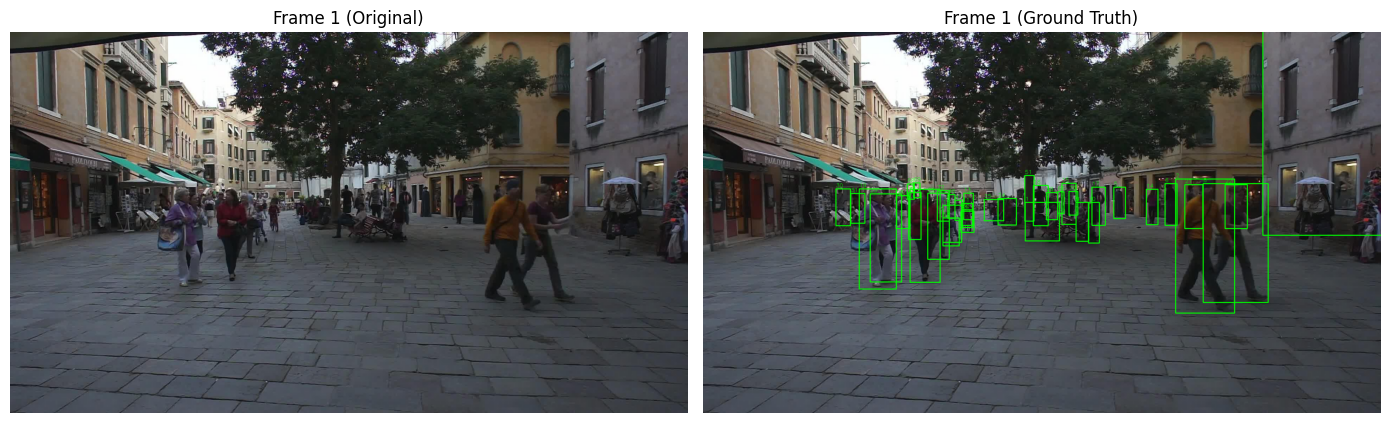

In [6]:
# visualising a sample image

# helper function for drawing ground truth boxes in images
def draw_boxes(img, boxes_df, color=(0, 255, 0)):
    img = img.copy()
    for _, row in boxes_df.iterrows():
        x, y, w, h = int(row["x"]), int(row["y"]), int(row["w"]), int(row["h"])
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
        cv2.putText(img, str(int(row["id"])), (x, max(y - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img

sample_frame = 1

image_path = os.path.join(IMG_DIR, f"{sample_frame:06d}.jpg")
if(os.path.exists(image_path)):
  print(f"Image found at {image_path}")
else:
  print(f"Image not found at {image_path}")
image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

sample_boxes = gt_df[gt_df["frame"] == sample_frame]

annotated_image = draw_boxes(image, sample_boxes)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Frame {sample_frame} (Original)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(annotated_image)
plt.title(f"Frame {sample_frame} (Ground Truth)")
plt.axis("off")

plt.tight_layout()
plt.show()


## Filtering for Pedestrian Tracking

Though MOT17 contains multiple object categories, we am using only pedestrians for assignment purpose. <br>
So, we modify detection model for single class detection (only pedestrians and background).

Therefore, only annotations for valid pedestrian (class = 1 and conf = 1) are used for training. <br>
This converts the dataset into a person-only multi-object tracking dataset, similar to SportsMOT.

In [7]:
gt_df = gt_df[
    (gt_df["class"] == 1) &
    (gt_df["conf"] == 1)
].reset_index(drop=True)

print(f"Remaining annotations : {len(gt_df)}")
print(f"Tracked pedestrians   : {gt_df['id'].nunique()}")

Remaining annotations : 18581
Tracked pedestrians   : 62


# 3. Fine tuning model
## Train-test split
- We split the train videos from dataset into into test and train sequences. One sequence represents a vido.
- It is done to so that model doesnot see test images during training. Using frames from same video in train and test causes data leakage, as the frames in a video are similar to each other.
- Only person class is considered from all categories.

In [8]:
TRAIN_SEQUENCES = [
    "MOT17-02-FRCNN",
    "MOT17-04-FRCNN",
    "MOT17-05-FRCNN",
    "MOT17-09-FRCNN",
    "MOT17-10-FRCNN",
]

TEST_SEQUENCES = [
    "MOT17-11-FRCNN",
    "MOT17-13-FRCNN",
]

BATCH_SIZE = 4

## Filtering dataset
- We filter dataset to remove negative coordinates, keep person classes
- We finally get a list of samples, each sample contain bounding boxes and classes for a frame of a sqeuence

In [9]:
# this function is going through database, keeps only valid people informatoin
# it emits list of samples, each sample has sequence name, frame path, label (person/bg), and bounding box coordinate
def build_samples(sequence_list):

    samples = []

    for sequence in sequence_list:

        seq_dir = os.path.join(DATA_ROOT, 'train', sequence)

        img_dir = os.path.join(seq_dir, "img1")
        gt_path = os.path.join(seq_dir, "gt", "gt.txt")

        gt_df = pd.read_csv(
            gt_path,
            header=None,
            names=COLUMN_NAMES,
        )

        # assuming all images in a sequence have same size
        sample_image = cv2.imread(os.path.join(img_dir, "000001.jpg"))
        image_height, image_width = sample_image.shape[:2]

        # Keep only valid pedestrian annotations
        # also remove entries where x,y,w or h are negative
        gt_df = gt_df[
            (gt_df["class"] == 1) &
            (gt_df["conf"] == 1) &
            (gt_df["x"] >= 0) &
            (gt_df["y"] >= 0) &
            (gt_df["w"] > 0) &
            (gt_df["h"] > 0)
        ]

        # Clip width and height so boxes stay inside the image
        gt_df["w"] = np.minimum(gt_df["w"], image_width - gt_df["x"])
        gt_df["h"] = np.minimum(gt_df["h"], image_height - gt_df["y"])

        # iterate all frames of the video, assuming no frame is skipped in dataset
        frame_paths = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))

        for frame_number, image_path in enumerate(frame_paths, start=1):

            frame_gt = gt_df[gt_df["frame"] == frame_number]

            boxes = frame_gt[["x", "y", "w", "h"]].values

            labels = [1] * len(boxes)

            samples.append({
                "sequence": sequence,
                "image_path": image_path,
                "boxes": boxes,
                "labels": labels,
            })

    return samples

- We make MOTDetectionDataset class which inherits from PyTorch's Dataset class
- This is used later by DataLoader class during model training and validation

In [10]:
from torch.utils.data import Dataset
import torchvision
import torch

# This class is pytorch virtual Dataset class
# later DataLoader class (pytorch) will use this to get Dataset
# I have to implement __len__ and __getitem__ here.

class MOTDetectionDataset(Dataset):

    def __init__(self, samples, augment=False):

        self.samples = samples
        self.augment = augment

        self.color_jitter = torchvision.transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        # Load image
        image = cv2.cvtColor(
            cv2.imread(sample["image_path"]),
            cv2.COLOR_BGR2RGB,
        )

        image_height, image_width = image.shape[:2]

        # Convert image to tensor
        # torchvision model is expecting imgs in CHW order and (0,1)range
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        # Ground truth
        boxes = np.asarray(sample["boxes"], dtype=np.float32)

        if len(boxes):
            boxes = boxes.copy()
            # MOT17 is giving x, y, w, h for a bounding box
            # pytorch is expecting xmin, ymin, xmax, ymax
            # doing the conversion here
            boxes[:, 2] += boxes[:, 0]
            boxes[:, 3] += boxes[:, 1]
        else:
            boxes = np.zeros((0, 4), dtype=np.float32)

        labels = np.asarray(sample["labels"], dtype=np.int64)

        # Data augmentation
        if self.augment:
            image = self.color_jitter(image)
            if random.random() < 0.5:
                image = torch.flip(image, dims=[2])
                if len(boxes):
                    boxes[:, [0, 2]] = image_width - boxes[:, [2, 0]]

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
        }

        return image, target

Here we make train and test samples and corresponding data loaders

In [13]:
train_samples = build_samples(TRAIN_SEQUENCES)
test_samples = build_samples(TEST_SEQUENCES)

print(f"Training frames : {len(train_samples)}")
print(f"Testing frames  : {len(test_samples)}")


train_dataset = MOTDetectionDataset(train_samples, augment=False)
val_dataset = MOTDetectionDataset(test_samples, augment=False)


def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size= BATCH_SIZE,
    shuffle=True,
    # shuffle=False,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size= BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

Training frames : 3666
Testing frames  : 1650


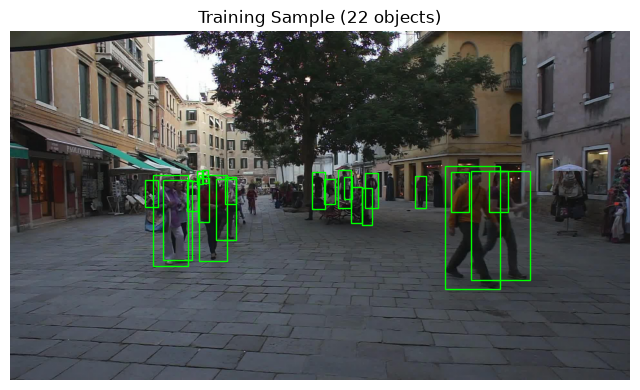

In [35]:
# Visualising a sample image here, using ground truth boxes
idx = random.randint(0, len(train_dataset) - 1)
img_t, target = train_dataset[idx]
img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
# print(target["labels"])
plt.figure(figsize=(8, 5))
plt.imshow(img_np)
ax = plt.gca()
for box in target["boxes"]:
    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=1))
plt.title(f"Training Sample ({len(target['boxes'])} objects)")
plt.axis("off")
plt.show()


## Model training

- Pretrained Faster R-CNN model is trained on COCO dataset and can detect different object categories (car, people etc.).
- For the MOT17 dataset, only pedestrians are of interest from assignment perspective, as I want to make a person tracking pipeline.
- So, we finetune pretrained model using transfer learning.

- The feature extraction backbone (ResNet-50 with Feature Pyramid Network), Region Proposal Network (RPN), and RoI feature extraction layers remain same with their pretrained weights.
- Only the final classification and bounding-box prediction head is replaced. The original prediction head, which outputs scores for all COCO classes, is substituted with a new head that predicts two classes, 0 for background and 1 for person.
- During training, the new prediction head is trained using MOT17 database, and it learns to classify proposals as either background or pedestrian.

In [15]:
NUM_CLASSES = 2  # background + player

def build_model(num_classes=NUM_CLASSES):
    # Load Faster R-CNN model pretrained on the COCO dataset.
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT) # base model
    # get input size of current box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # use a new box predictor, input features remain same, but emits for two classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = build_model().to(device)

Resumed from checkpoint at epoch 5 (of 5)
Checkpoint already reached NUM_EPOCHS — skipping training.


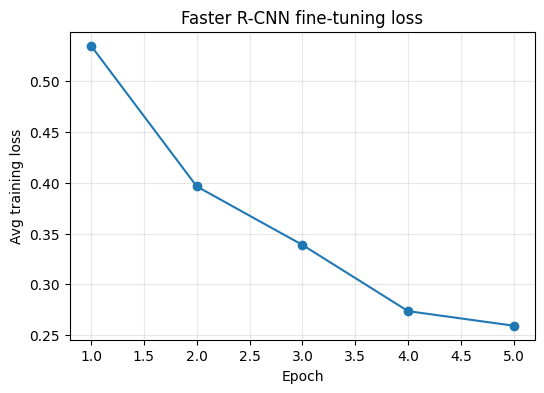

In [16]:
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad], lr=0.005, momentum=0.9, weight_decay=0.0005
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

NUM_EPOCHS = 5

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "fasterrcnn_checkpoint.pt")

start_epoch = 0
train_losses = []
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    lr_scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    train_losses = checkpoint["train_losses"]
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch} (of {NUM_EPOCHS})")

if start_epoch >= NUM_EPOCHS:
    print("Checkpoint already reached NUM_EPOCHS — skipping training.")
else:
    model.train()
    for epoch in range(start_epoch, NUM_EPOCHS):
        epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")
        for batch_idx, (images, targets) in enumerate(pbar):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)

            loss = sum(loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        lr_scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}: avg loss = {avg_loss:.4f}")

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": lr_scheduler.state_dict(),
            "train_losses": train_losses,
        }, CHECKPOINT_PATH)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Avg training loss")
plt.title("Faster R-CNN fine-tuning loss")
plt.grid(alpha=0.3)
plt.show()


In [34]:
# a helper function, it infers on an image and returns filtered detection boxes
DETECTION_SCORE_THRESH = 0.7

@torch.no_grad()
def detect(model, img_t):
    model.eval()
    output = model([img_t.to(device)])[0]
    keep = output["scores"] >= DETECTION_SCORE_THRESH
    boxes = output["boxes"][keep].cpu().numpy()
    scores = output["scores"][keep].cpu().numpy()
    return boxes, scores


# 4. Evaluate detection accuracy

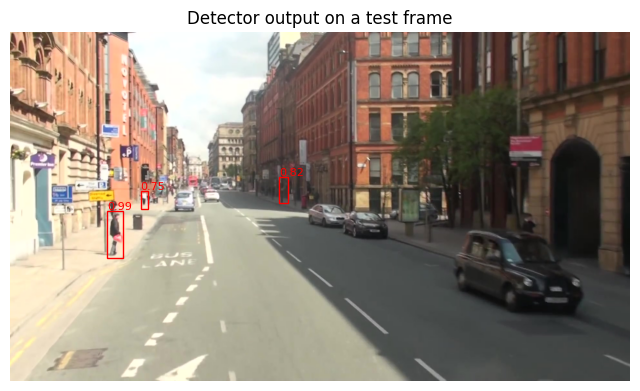

In [28]:
# Visualizing detector output
_val_idx = random.randint(0, len(val_dataset))
img_t, target = val_dataset[_val_idx]
boxes, scores = detect(model, img_t)

img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
plt.figure(figsize=(8, 5))
plt.imshow(img_np)
ax = plt.gca()
for box, score in zip(boxes, scores):
    x1, y1, x2, y2 = box
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1))
    ax.text(x1, max(y1 - 4, 0), f"{score:.2f}", color="red", fontsize=8)
plt.title("Detector output on a test frame")
plt.axis("off")
plt.show()

## Mean average Precision score

We are running inferences on validation images, and cache the results to disk.<br>
This is done to control memory usage, and do faster iterations.

In [19]:
DETS_CACHE_PATH = os.path.join(ROOT_DIR, "map_predictions")
os.makedirs(DETS_CACHE_PATH, exist_ok=True)

SAVE_EVERY = 50 # Save after every N images
# RESUME = True         # Resume if checkpoint exists

model.eval()

buffer = []
processed = 0
chunk_idx = 0


# Resume from existing chunks
existing_chunks = sorted(glob.glob(os.path.join(DETS_CACHE_PATH, "chunk_*.pt")))

if existing_chunks:
    chunk_idx = len(existing_chunks)
    processed = chunk_idx * SAVE_EVERY
    print(f"Found {chunk_idx} existing chunks ({processed} images). Resuming...")

with torch.no_grad():

    image_idx = 0

    for images, targets in tqdm(val_loader, desc="Inference"):

        # Skip images already processed
        if image_idx < processed:
            image_idx += len(images)
            continue

        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):

            buffer.append({
                "prediction": {
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu(),
                },
                "ground_truth": {
                    "boxes": tgt["boxes"].cpu(),
                    "labels": tgt["labels"].cpu(),
                }
            })
            image_idx += 1
            if len(buffer) == SAVE_EVERY:

                chunk_path = os.path.join(DETS_CACHE_PATH,
                    f"chunk_{chunk_idx:04d}.pt")

                torch.save(buffer, chunk_path)
                print(f"Saved {chunk_path}")
                buffer.clear()
                chunk_idx += 1

# Save remaining images
if buffer:
    chunk_path = os.path.join(DETS_CACHE_PATH, f"chunk_{chunk_idx:04d}.pt")
    torch.save(buffer, chunk_path)
    print(f"Saved {chunk_path}")

print("Inference complete.")


Found 1 existing chunks (50 images). Resuming...


Inference:   0%|          | 0/413 [00:00<?, ?it/s]

Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0001.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0002.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0003.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0004.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0005.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0006.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0007.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0008.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0009.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0010.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0011.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map_predictions/chunk_0012.pt
Saved /content/drive/MyDrive/sem2/CV/Assignment2/map

In [36]:
# Calculating mean average precision using inferences above
metric = MeanAveragePrecision(iou_type="bbox")

chunk_files = sorted(glob.glob(os.path.join(DETS_CACHE_PATH, "chunk_*.pt")))

for chunk_file in tqdm(chunk_files, desc="Evaluating"):

    chunk = torch.load(chunk_file)

    preds = []
    gts = []

    for sample in chunk:

        preds.append(sample["prediction"])
        gts.append(sample["ground_truth"])

    metric.update(preds, gts)

map_result = metric.compute()

print(f"mAP@[0.5:0.95] : {map_result['map']:.4f}")
print(f"mAP@0.50       : {map_result['map_50']:.4f}")
print(f"mAP@0.75       : {map_result['map_75']:.4f}")

NameError: name 'DETS_CACHE_PATH' is not defined

# 5 Tracking — Kalman filter + SORT + temporal consistency + adaptive gating

- **Kalman filter**: constant-velocity motion model per track (standard SORT state
  `[cx, cy, s, r, vx, vy, vs]`).
- **Temporal consistency**: a track's ID is only reported once it has been matched for
  `min_hits` consecutive frames (or during the initial warm-up window) — this suppresses
  flickering identities from single spurious detections.
- **Adaptive tracking**: the IoU gate used for matching loosens as a track's estimated
  speed increases, since fast-moving objects have less reliable position predictions.


In [23]:
# helper function to calculate IOU between two boxes
def iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b
    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_w, inter_h = max(0.0, inter_x2 - inter_x1), max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area
    return inter_area / union if union > 0 else 0.0


class KalmanBoxTracker:
    """Constant-velocity Kalman filter tracking a single object's bbox (cx, cy, s, r)."""

    count = 0

    def __init__(self, bbox):
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([
            [1, 0, 0, 0, 1, 0, 0],
            [0, 1, 0, 0, 0, 1, 0],
            [0, 0, 1, 0, 0, 0, 1],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 1],
        ])
        self.kf.H = np.array([
            [1, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0],
        ])
        self.kf.R[2:, 2:] *= 10.0
        self.kf.P[4:, 4:] *= 1000.0
        self.kf.P *= 10.0
        self.kf.Q[-1, -1] *= 0.01
        self.kf.Q[4:, 4:] *= 0.01
        self.kf.x[:4] = self._to_z(bbox)

        KalmanBoxTracker.count += 1
        self.id = KalmanBoxTracker.count
        self.hits = 1
        self.hit_streak = 1
        self.time_since_update = 0

    @staticmethod
    def _to_z(bbox):
        x1, y1, x2, y2 = bbox
        w, h = x2 - x1, y2 - y1
        cx, cy = x1 + w / 2, y1 + h / 2
        s = w * h
        r = w / h if h != 0 else 0.0
        return np.array([cx, cy, s, r]).reshape((4, 1))

    @staticmethod
    def _to_bbox(x):
        cx, cy, s, r = x[:4].reshape(-1)
        w = np.sqrt(max(s * r, 0.0))
        h = s / w if w != 0 else 0.0
        return np.array([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2])

    def predict(self):
        if (self.kf.x[6] + self.kf.x[2]) <= 0:
            self.kf.x[6] *= 0.0
        self.kf.predict()
        if self.time_since_update > 0:
            self.hit_streak = 0
        self.time_since_update += 1
        return self._to_bbox(self.kf.x)

    def update(self, bbox):
        self.time_since_update = 0
        self.hits += 1
        self.hit_streak += 1
        self.kf.update(self._to_z(bbox))

    def get_state(self):
        return self._to_bbox(self.kf.x)

    def speed(self):
        vx, vy = self.kf.x[4, 0], self.kf.x[5, 0]
        return float(np.hypot(vx, vy))


class SortTracker:
    def __init__(self, max_age=15, min_hits=3, base_iou_threshold=0.3):
        self.max_age = max_age
        self.min_hits = min_hits
        self.base_iou_threshold = base_iou_threshold
        self.trackers = []
        self.frame_count = 0

    def _adaptive_threshold(self, trk)
        speed = trk.speed()
        return max(0.1, self.base_iou_threshold - min(0.15, speed * 0.01))

    def update(self, detections):
        self.frame_count += 1
        predicted_boxes = [trk.predict() for trk in self.trackers]

        matches, unmatched_dets, unmatched_trks = self._associate(detections, predicted_boxes)

        for t_idx, d_idx in matches:
            self.trackers[t_idx].update(detections[d_idx])

        for d_idx in unmatched_dets:
            self.trackers.append(KalmanBoxTracker(detections[d_idx]))

        results, alive = [], []
        for trk in self.trackers:
            if trk.time_since_update < self.max_age:
                alive.append(trk)
                if trk.time_since_update < 1 and (
                    trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits
                ):
                    results.append((trk.id, trk.get_state()))
        self.trackers = alive
        return results

    def _associate(self, detections, predicted_boxes):
        if len(self.trackers) == 0 or len(detections) == 0:
            return [], list(range(len(detections))), list(range(len(self.trackers)))

        iou_matrix = np.zeros((len(self.trackers), len(detections)), dtype=np.float32)
        for t, pbox in enumerate(predicted_boxes):
            for d, dbox in enumerate(detections):
                iou_matrix[t, d] = iou(pbox, dbox)

        row_idx, col_idx = linear_sum_assignment(-iou_matrix)

        matches, unmatched_trks, unmatched_dets = [], [], []
        matched_rows, matched_cols = set(row_idx), set(col_idx)
        for t in range(len(self.trackers)):
            if t not in matched_rows:
                unmatched_trks.append(t)
        for d in range(len(detections)):
            if d not in matched_cols:
                unmatched_dets.append(d)

        for t, d in zip(row_idx, col_idx):
            if iou_matrix[t, d] < self._adaptive_threshold(self.trackers[t]):
                unmatched_trks.append(t)
                unmatched_dets.append(d)
            else:
                matches.append((t, d))

        return matches, unmatched_dets, unmatched_trks


In [29]:
def id_to_color(track_id):
    rng = np.random.RandomState(track_id)
    return tuple(int(c) for c in rng.randint(60, 255, size=3))


KalmanBoxTracker.count = 0
tracker = SortTracker(max_age=15, min_hits=3, base_iou_threshold=0.3)

track_results = []

sample_idxs = set(np.linspace(0, len(test_samples) - 1, 4).astype(int))
sample_frames = {}

out_path = os.path.join(CHECKPOINT_DIR, "tracked_output.mp4")

# Get video size from first image
first_img = cv2.cvtColor(cv2.imread(test_samples[0]["image_path"]),cv2.COLOR_BGR2RGB,)
h, w = first_img.shape[:2]
writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), 20, (w, h))

current_sequence = None
counter = None
for sample_idx, sample in enumerate(tqdm(test_samples, desc="Tracking")):

    # Restart tracker when a new video begins
    if sample["sequence"] != current_sequence:
        tracker = SortTracker(max_age=15,min_hits=3,base_iou_threshold=0.3,)
        current_sequence = sample["sequence"]
        counter = 0

    img = cv2.cvtColor(cv2.imread(sample["image_path"]),cv2.COLOR_BGR2RGB,)

    img_t = torch.from_numpy(img).permute(2, 0, 1).float().div(255.0)
    boxes, _ = detect(model, img_t)
    tracked = tracker.update(boxes)
    vis = img.copy()

    frame_number = os.path.splitext(os.path.basename(sample["image_path"]))[0]

    for tid, box in tracked:
        x1, y1, x2, y2 = box.astype(int)
        color = id_to_color(tid)

        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

        label = f"ID {tid}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        thickness = 1
        padding = 2

        (text_w, text_h), baseline = cv2.getTextSize(label, font, font_scale, thickness)

        # Position the label above the box if possible
        text_x = x1
        text_y = max(y1 - 5, text_h + padding)

        # White background rectangle
        cv2.rectangle(
            vis,
            (text_x - padding, text_y - text_h - padding),
            (text_x + text_w + padding, text_y + baseline + padding),
            (255, 255, 255), thickness=-1,)

        # Black text
        cv2.putText(
            vis, label,
            (text_x, text_y),
            font, font_scale,
            (0, 0, 0),
            thickness, cv2.LINE_AA,
        )

        track_results.append({
            "sequence": sample["sequence"],
            "frame": int(frame_number),
            "id": tid,
            "x": x1,
            "y": y1,
            "w": x2 - x1,
            "h": y2 - y1,
        })

    writer.write(cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

    if sample_idx in sample_idxs:
        sample_frames[sample_idx] = vis

writer.release()

track_df = pd.DataFrame(track_results)

print(
    f"Tracked {track_df['id'].nunique()} unique IDs "
    f"over {len(test_samples)} frames."
)

print(f"Annotated video saved to {out_path}")

Tracking:   0%|          | 0/1650 [00:00<?, ?it/s]

Tracked 288 unique IDs over 1650 frames.
Annotated video saved to /content/drive/MyDrive/sem2/CV/Assignment2/tracked_output.mp4


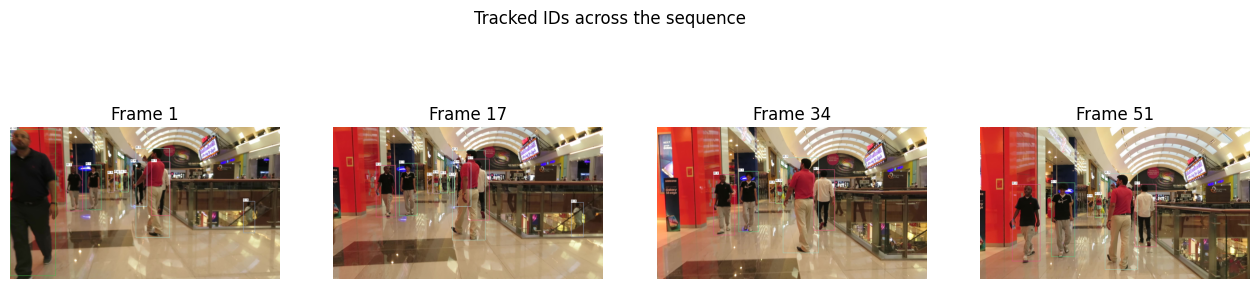

In [25]:
fig, axes = plt.subplots(1, len(sample_frames), figsize=(16, 4))
axes = np.atleast_1d(axes)
for ax, idx in zip(axes, sorted(sample_frames)):
    ax.imshow(sample_frames[idx])
    ax.set_title(f"Frame {idx + 1}")
    ax.axis("off")
plt.suptitle("Tracked IDs across the sequence")
plt.show()

# 6. Tracking Evaluation
## Tracking — MOTA / MOTP / IDF1 / ID switches (via `py-motmetrics`)

In [32]:
def build_accumulator(gt_df, trk_df):
    """Build MOT accumulator for one sequence."""

    acc = mm.MOTAccumulator(auto_id=True)
    empty_cols = ["frame", "id", "x", "y", "w", "h"]

    for frame in sorted(gt_df["frame"].unique()):
        gt_frame = gt_df[gt_df["frame"] == frame]

        if len(trk_df):
            trk_frame = trk_df[trk_df["frame"] == frame]
        else:
            trk_frame = pd.DataFrame(columns=empty_cols)

        gt_boxes = gt_frame[["x", "y", "w", "h"]].values
        trk_boxes = trk_frame[["x", "y", "w", "h"]].values

        dist_matrix = mm.distances.iou_matrix(gt_boxes, trk_boxes, max_iou=0.5,)

        acc.update(gt_frame["id"].tolist(),
            trk_frame["id"].tolist(), dist_matrix,)
    return acc

mh = mm.metrics.create()

accumulators = []
names = []

for sequence in TEST_SEQUENCES:

    print(f"Evaluating {sequence}")

    gt_path = os.path.join(DATA_ROOT, "train",sequence, "gt", "gt.txt",)
    gt_df = pd.read_csv(gt_path, header=None, names=COLUMN_NAMES,)

    # Keep only valid pedestrian annotations
    gt_df = gt_df[
        (gt_df["class"] == 1) &
        (gt_df["conf"] == 1)
    ].reset_index(drop=True)

    # Tracker output for this sequence
    trk_df = track_df[track_df["sequence"] == sequence].copy()

    acc = build_accumulator(gt_df, trk_df)

    accumulators.append(acc)
    names.append(sequence)


summary = mh.compute_many(
    accumulators, names=names,
    metrics=[
        "mota",
        "motp",
        "idf1",
        "num_switches",
        "num_false_positives",
        "num_misses",
    ],
    generate_overall=True,
)

summary

Evaluating MOT17-11-FRCNN
Evaluating MOT17-13-FRCNN


,mota,motp,idf1,num_switches,num_false_positives,num_misses
MOT17-11-FRCNN,0.588491,0.151850,0.585827,41,472,3370
MOT17-13-FRCNN,0.209414,0.243987,0.332609,100,730,8374
OVERALL,0.379116,0.184109,0.460555,141,1202,11744


# 7. Analysis & Justification

### Detection

- Fine-tuning reduced the training loss consistently over 5 epochs, indicating successful adaptation of the detector to pedestrian detection.
- The detector achieved **mAP@[0.5:0.95] = 0.555** and **mAP@0.5 = 0.809**, demonstrating good pedestrian detection performance.
- The gap between the two metrics suggests that while pedestrians are reliably detected, bounding-box localization can still be improved with additional fine-tuning.

### Tracking Performance

| Sequence | MOTA | IDF1 |
|----------|-----:|------:|
| MOT17-11-FRCNN | 0.588 | 0.586 |
| MOT17-13-FRCNN | 0.209 | 0.333 |
| **Overall** | **0.379** | **0.461** |

- Tracking performance is significantly better on **MOT17-11** than on **MOT17-13**, indicating that performance degrades in more crowded and challenging scenes.
- The lower performance on **MOT17-13** is primarily due to a larger number of missed detections.

### Error Analysis

- **False positives:** 1202
- **Missed detections:** 11744
- **Identity switches:** 141

Observations:

- Missed detections are the dominant source of tracking error.
- Identity switches are relatively few compared to the number of missed detections, indicating that the Kalman filter and Hungarian matching maintain stable identities once objects are detected.
- Most failures occur when pedestrians become heavily occluded or leave the field of view, causing tracks to be terminated and new identities to be assigned upon reappearance.

### Limitations

- SORT depends entirely on detector quality; missed detections cannot be recovered.
- The constant-velocity Kalman model becomes less reliable during long occlusions or abrupt motion changes.
- No appearance (ReID) features are used, making recovery of identities after long occlusions difficult.
- The detector runs at approximately **7.4 FPS** on the Colab GPU. This is suitable for offline processing but below real-time performance requirements.